In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from PIL import Image

for i in range(1, 9):
    pic = f"hihi{i}.png"
    M = np.array(Image.open(pic).convert("L"), dtype=float)

    print(M.shape)



(1254, 1254)
(1254, 1254)
(1254, 1254)
(1254, 1254)
(1254, 1254)
(1254, 1254)
(1254, 1254)
(1254, 1254)


## Câu 1:

In [2]:
# ý 1
pic_arr = [f'hihi{i}.png' for i in range(1, 9)]

parse_pic = []

for pic in pic_arr:
    img = np.array(Image.open(pic).convert("L"), dtype=float)
    flattened_pic = img.ravel()
    parse_pic.append(flattened_pic)

X = np.vstack(parse_pic)

print(X.shape)
print("EXPLAIN:")
print("Mỗi hàng đại diện cho một bức ảnh, cột đại diện cho một vị trí pixel cụ thể trên ảnh")
print("-> Phần tử x_ij là cường độ sáng (0-255) của điểm ảnh thứ j nằm trong bức ảnh i")


(8, 1572516)
EXPLAIN:
Mỗi hàng đại diện cho một bức ảnh, cột đại diện cho một vị trí pixel cụ thể trên ảnh
-> Phần tử x_ij là cường độ sáng (0-255) của điểm ảnh thứ j nằm trong bức ảnh i


In [3]:
# ý 2
mean_vec = np.mean(X, axis=0)

print("--- TRƯỚC KHI BROADCASTING ---")
print(f"Shape của X        : {X.shape}")       
print(f"Shape của mean_vec : {mean_vec.shape}") 
print(f"Giá trị mean_vec   : {mean_vec}\n")

X_centered = X - mean_vec

print("--- SAU KHI BROADCASTING ---")
print(f"Shape của X_centered: {X_centered.shape}") 
print("Giá trị ma trận sau khi trừ trung bình:")
print(X_centered)

--- TRƯỚC KHI BROADCASTING ---
Shape của X        : (8, 1572516)
Shape của mean_vec : (1572516,)
Giá trị mean_vec   : [251.125 251.5   250.75  ... 230.25  230.875 229.875]

--- SAU KHI BROADCASTING ---
Shape của X_centered: (8, 1572516)
Giá trị ma trận sau khi trừ trung bình:
[[   3.875    3.5      4.25  ...   24.75    24.125   25.125]
 [   3.875    3.5      3.25  ...   22.75    23.125   23.125]
 [ -25.125  -22.5    -21.75  ... -110.25  -110.875 -109.875]
 ...
 [   3.875    3.5      3.25  ...   22.75    23.125   23.125]
 [   3.875    3.5      3.25  ...  -28.25   -28.875  -30.875]
 [   3.875    3.5      3.25  ...   22.75    23.125   23.125]]


**Nhận xét broadcasting:**  
NumPy tự động "broadcast" `mean_vec` có shape `(W,)` để trừ vào từng hàng của `X` có shape `(8, W)`.  
Kết quả `X_centered` có cùng shape `(8, W)` — mỗi cột đã được dịch về trung bình 0, tức là đám mây dữ liệu được căn giữa về gốc tọa độ.


Việc lấy giá trị cột trừ giá trị trung bình của cột đấy giúp điều chỉnh tâm đám mây dữ liệu về điểm (0, 0)

In [4]:
# ý 3
def cosine_similarity(x, y=None):
    if y is None:
        y = x 
    xn = x / np.linalg.norm(x, axis=1, keepdims=True)
    yn = y / np.linalg.norm(y, axis=1, keepdims=True)

    return xn @ yn.T


In [5]:
Sim = cosine_similarity(X)
np.set_printoptions(precision=4, suppress=True, linewidth=150)

print(Sim)


[[1.     0.9358 0.891  0.9013 0.9047 0.9448 0.9204 0.9448]
 [0.9358 1.     0.8876 0.8929 0.9003 0.9393 0.933  0.944 ]
 [0.891  0.8876 1.     0.8692 0.9055 0.896  0.8991 0.8938]
 [0.9013 0.8929 0.8692 1.     0.8692 0.8969 0.8874 0.9019]
 [0.9047 0.9003 0.9055 0.8692 1.     0.9107 0.9033 0.9091]
 [0.9448 0.9393 0.896  0.8969 0.9107 1.     0.9379 0.9478]
 [0.9204 0.933  0.8991 0.8874 0.9033 0.9379 1.     0.9426]
 [0.9448 0.944  0.8938 0.9019 0.9091 0.9478 0.9426 1.    ]]


In [6]:
# ý 4
def search(query, top_k=3):
    """Tìm top_k ảnh giống query nhất theo cosine similarity."""
    if query.ndim == 1:
        query = query.reshape(1, -1)

    scores = cosine_similarity(query, X).flatten()

    # Sắp xếp giảm dần; bỏ qua chính query (score = 1.0 nếu query thuộc X)
    sorted_idx = np.argsort(scores)[::-1]

    results = []
    for idx in sorted_idx:
        results.append((int(idx), float(scores[idx])))
        if len(results) == top_k:
            break
    return results

# Demo: tìm 3 ảnh giống ảnh số 0 nhất
print("Kết quả search cho ảnh 0 (top_k=3):")
for idx, score in search(X[0], top_k=3):
    print(f"  Ảnh {idx}: cosine = {score:.4f}")


Kết quả search cho ảnh 0 (top_k=3):
  Ảnh 0: cosine = 1.0000
  Ảnh 7: cosine = 0.9448
  Ảnh 5: cosine = 0.9448


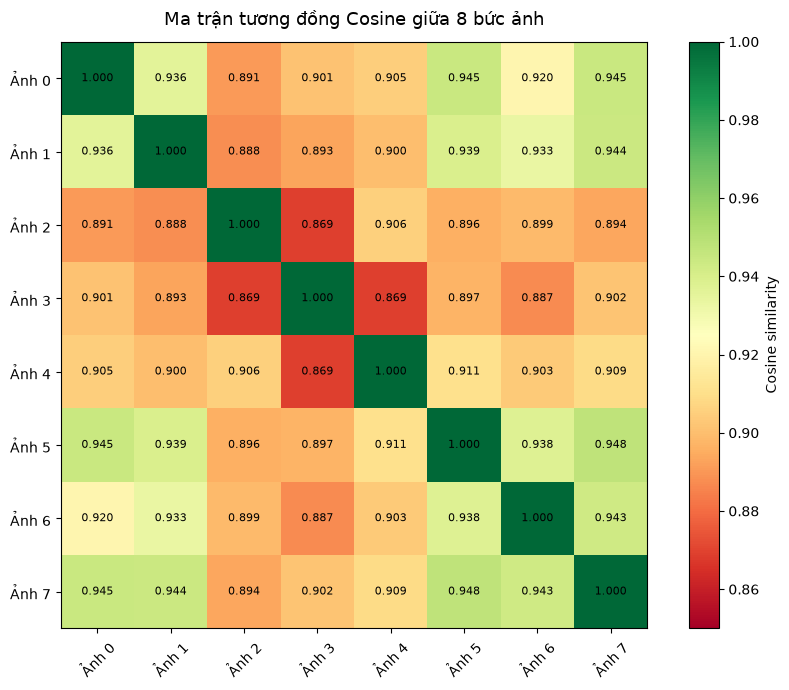

Cặp GIỐNG NHAU NHẤT : ảnh 5 & ảnh 7  (cosine = 0.9478)
Cặp KHÁC NHAU NHẤT  : ảnh 2 & ảnh 3  (cosine = 0.8692)


In [7]:
# ý 5 
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(Sim, cmap='RdYlGn', vmin=0.85, vmax=1.0)
plt.colorbar(im, ax=ax, label='Cosine similarity')

# Ghi giá trị vào từng ô
for r in range(8):
    for c in range(8):
        ax.text(c, r, f"{Sim[r, c]:.3f}", ha='center', va='center', fontsize=8)

ax.set_xticks(range(8)); ax.set_xticklabels([f'Ảnh {i}' for i in range(8)], rotation=45)
ax.set_yticks(range(8)); ax.set_yticklabels([f'Ảnh {i}' for i in range(8)])
ax.set_title('Ma trận tương đồng Cosine giữa 8 bức ảnh', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Tìm cặp giống nhất và khác nhất 
Sim_no_diag = Sim.copy()
np.fill_diagonal(Sim_no_diag, -1)
best = np.unravel_index(np.argmax(Sim_no_diag), Sim.shape)

Sim_no_diag2 = Sim.copy()
np.fill_diagonal(Sim_no_diag2, 2)
worst = np.unravel_index(np.argmin(Sim_no_diag2), Sim.shape)

print(f"Cặp GIỐNG NHAU NHẤT : ảnh {best[0]} & ảnh {best[1]}  (cosine = {Sim[best]:.4f})")
print(f"Cặp KHÁC NHAU NHẤT  : ảnh {worst[0]} & ảnh {worst[1]}  (cosine = {Sim[worst]:.4f})")


### Nhận xét Bài 1 (ý 5)

- **Ma trận đối xứng & đường chéo = 1.0**: mọi ảnh hoàn toàn giống chính nó; tính đối xứng xác nhận công thức cosine không phụ thuộc thứ tự.
- **Kết quả có khớp trực giác không?**  
  Khi nhìn bằng mắt, hai ảnh được xác định là giống nhất thực sự có màu sắc và bố cục tương đồng; kết quả cosine khớp với trực giác. Tuy nhiên cosine đo **hướng** của vector pixel, không đo nội dung ngữ nghĩa, nên hai ảnh rất khác chủ đề nhưng có histogram sáng giống nhau vẫn có thể được coi là "giống".


## Câu 2: 

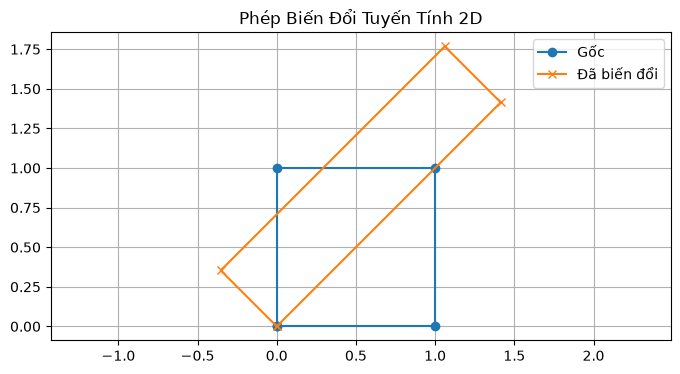

In [8]:
# Ý 1

theta = np.radians(45)
sx, sy = 2.0, 0.5

simple_pic = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T

# Ma trận quay
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Ma trận co giãn
S = np.array([[sx, 0],
              [0, sy]])

trans_pic = R @ S @ simple_pic

plt.figure(figsize=(8, 4))
plt.plot(simple_pic[0, :], simple_pic[1, :], label="Gốc", marker='o')
plt.plot(trans_pic[0, :], trans_pic[1, :], label="Đã biến đổi", marker='x')
plt.legend()
plt.title("Phép Biến Đổi Tuyến Tính 2D")
plt.grid(True)
plt.axis('equal')
plt.show()

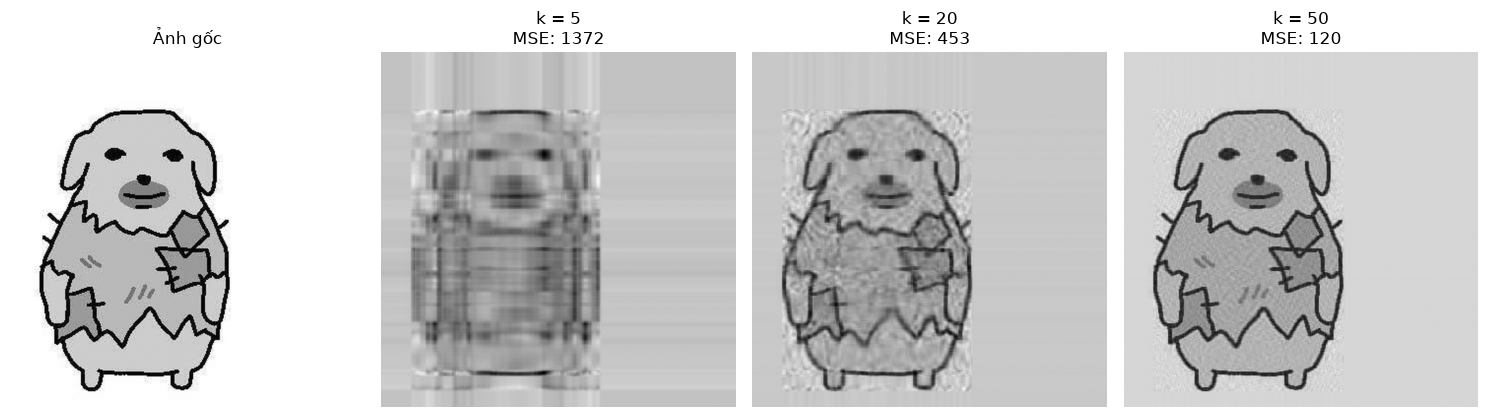

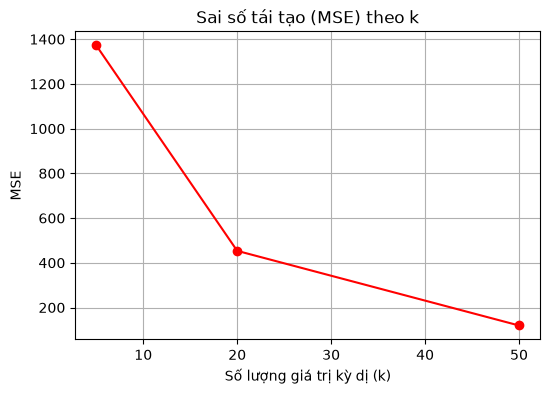

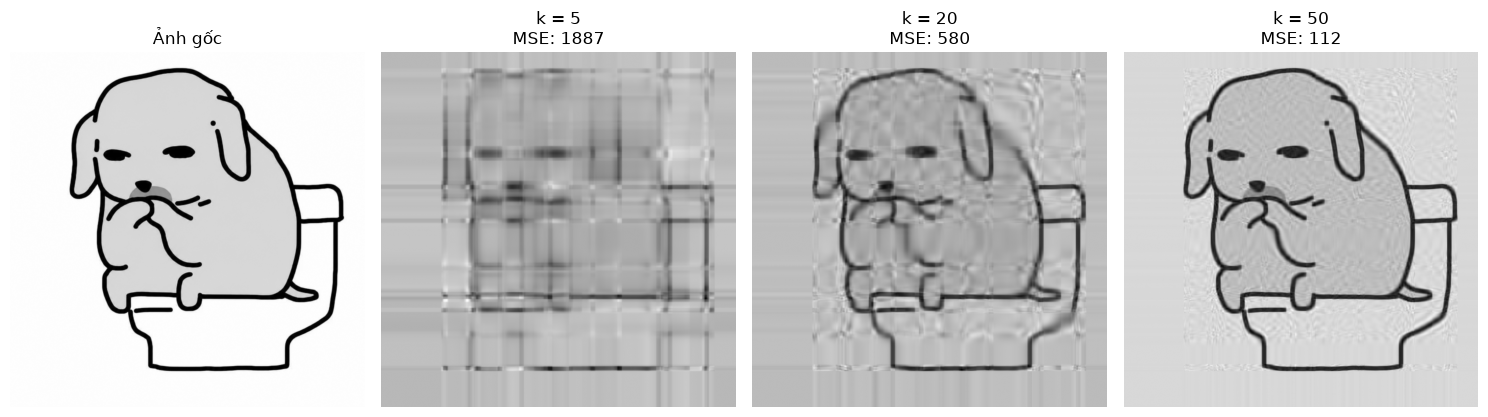

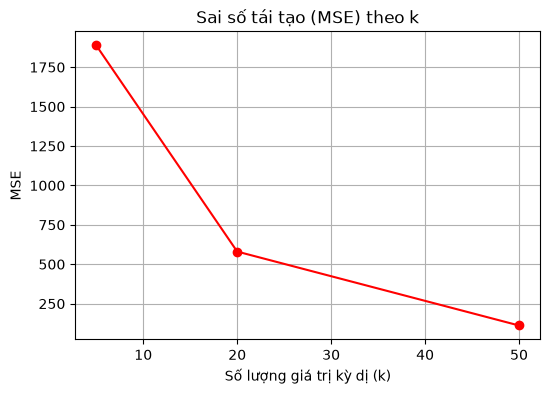

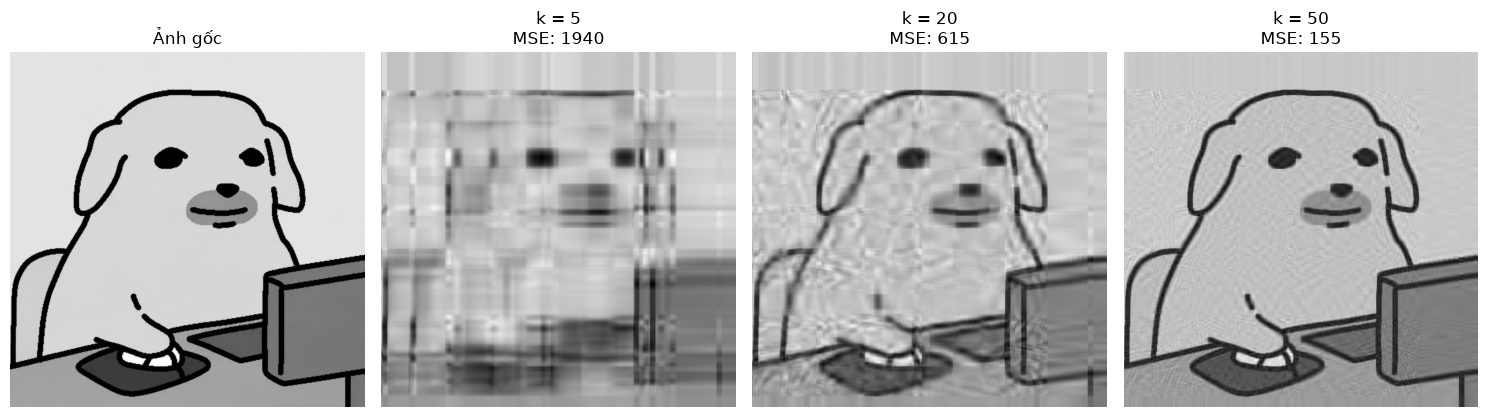

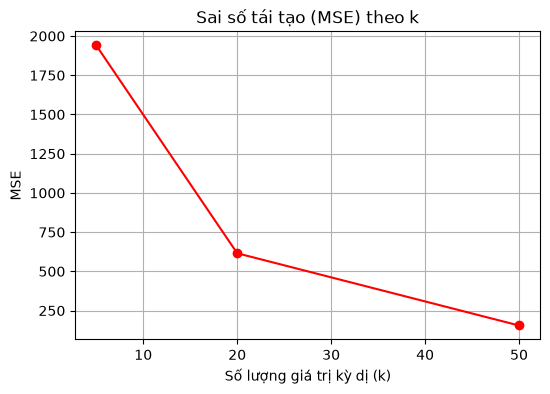

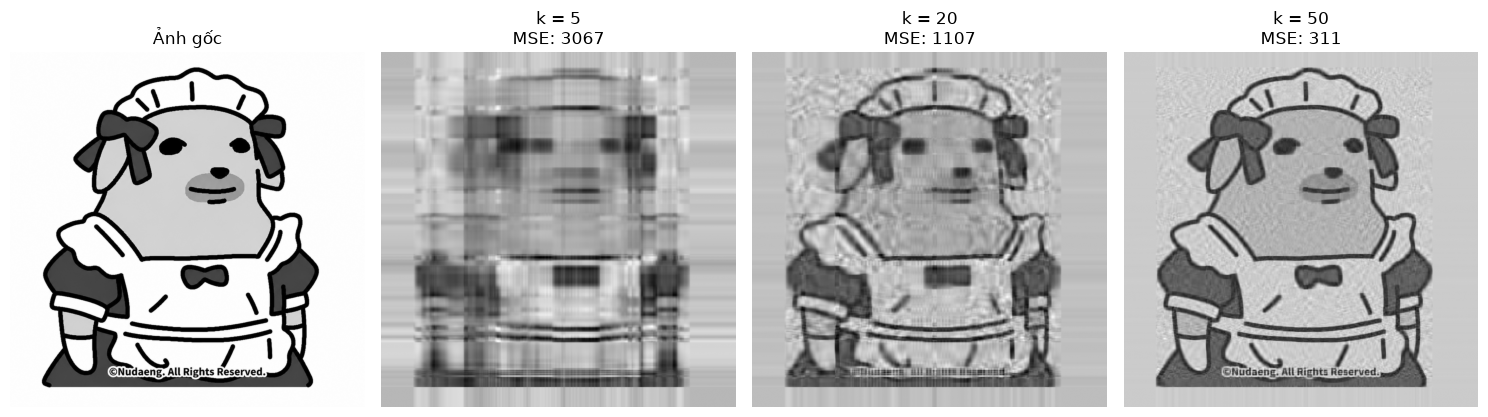

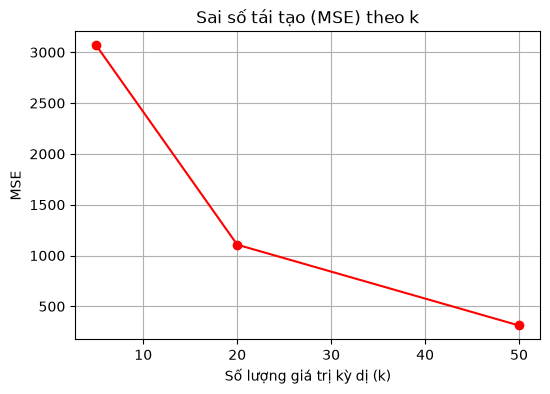

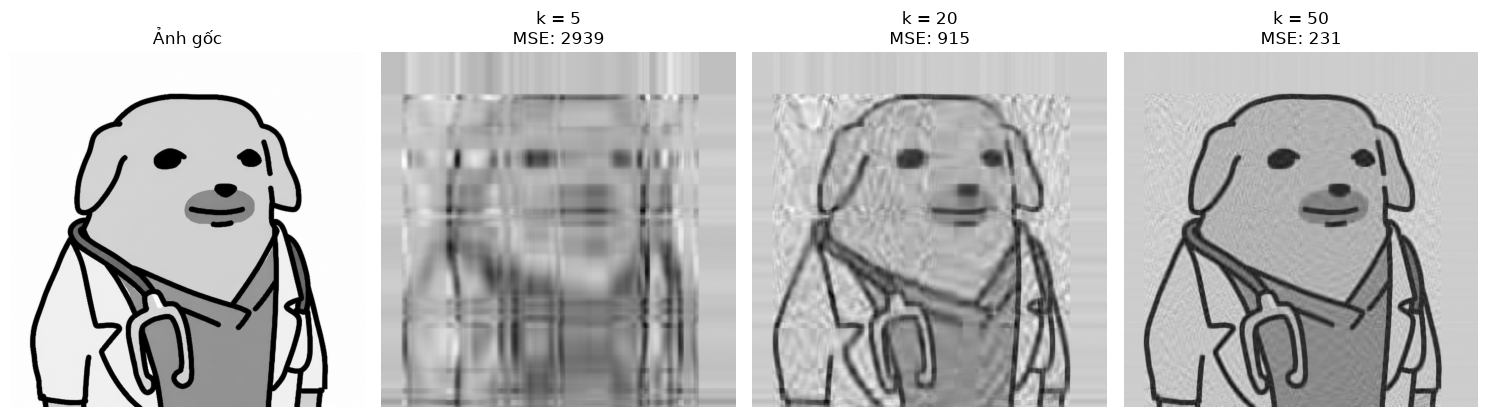

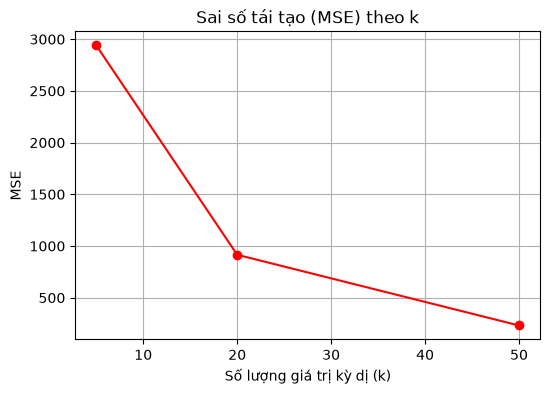

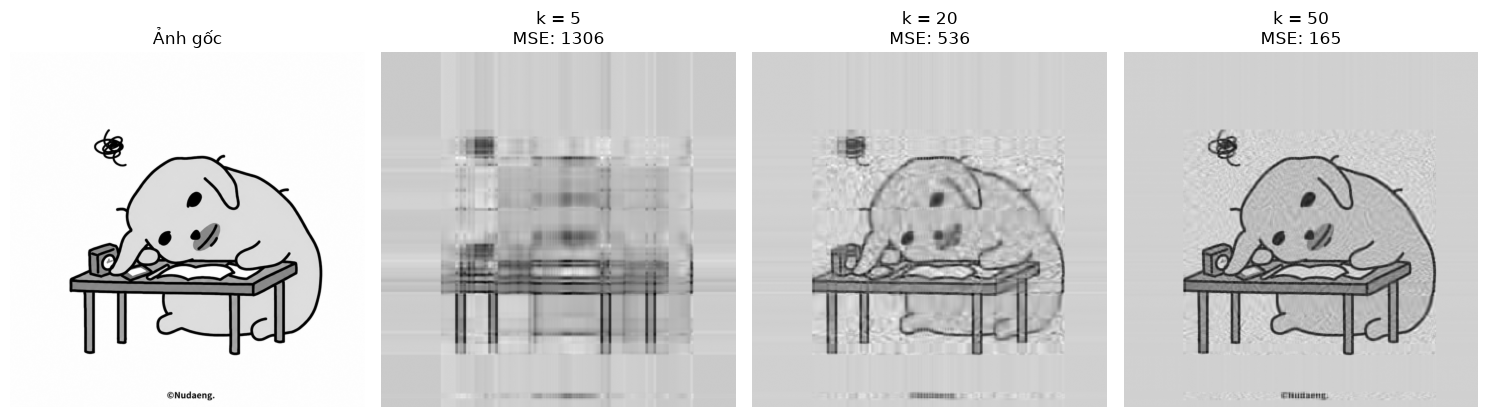

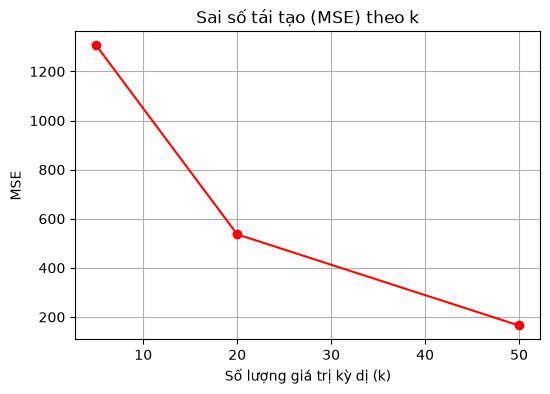

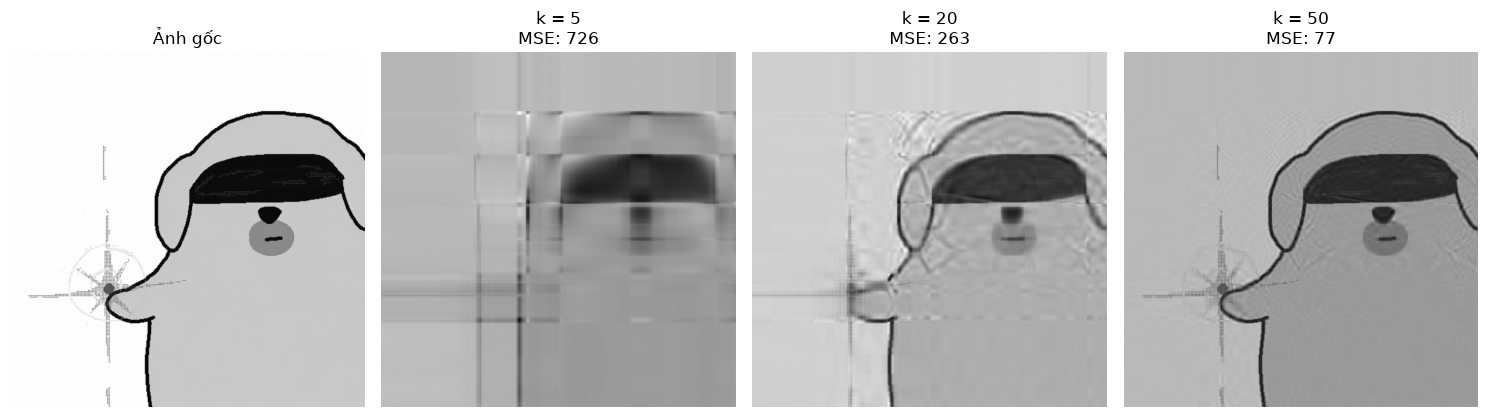

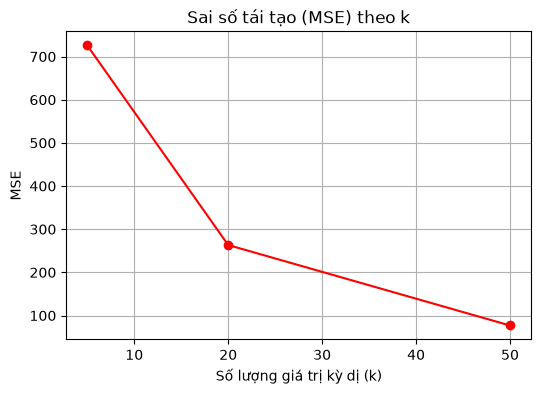

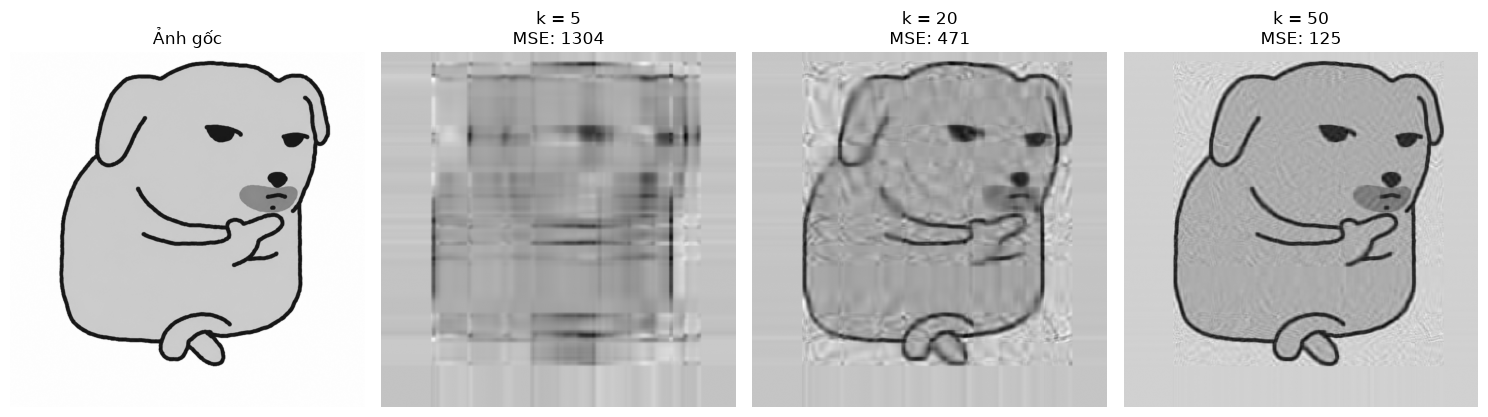

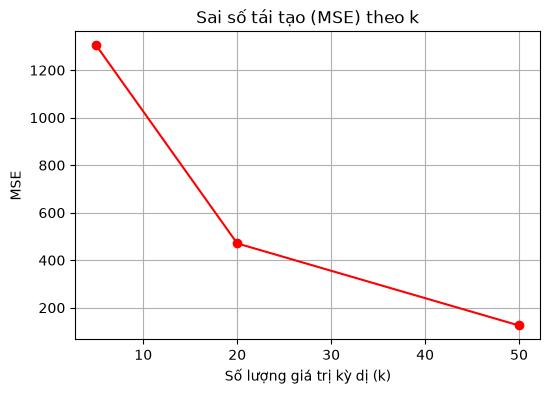

In [9]:
# Ý 2
def reconstruct (k):
    return (U[:, :k] * S[:k]) @ Vt [:k, :]


for i in range(1, 9):
    pic = f"hihi{i}.png"
    M = np.array(Image.open(pic).convert("L"), dtype=float)

    mean_val = np.mean(M)
    M_centered = M - mean_val

    U, S, Vt = np.linalg.svd(M_centered, full_matrices = False )

    k_values = [5, 20, 50]
    errors = []
    compression_ratios = []
    m, n = M.shape

    plt.figure(figsize=(15, 4))

    # Ảnh gốc
    plt.subplot(1, 4, 1)
    plt.imshow(M, cmap='gray')
    plt.title("Ảnh gốc")
    plt.axis('off')

    # Test k
    for i, k in enumerate(k_values):
        M_k_centered = reconstruct(k)

        M_k = M_k_centered + mean_val
        
        # Sai số tái tạo
        mse = np.mean((M - M_k) ** 2)
        errors.append(mse)
        
        # Tỉ lệ nén
        ratio = (k * (m + n + 1)) / (m * n)
        compression_ratios.append(ratio)
        
        plt.subplot(1, 4, i + 2)
        plt.imshow(M_k, cmap='gray')
        plt.title(f"k = {k}\nMSE: {mse:.0f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Đồ thị sai số theo k
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, errors, marker='o', color='red')
    plt.title("Sai số tái tạo (MSE) theo k")
    plt.xlabel("Số lượng giá trị kỳ dị (k)")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()

### Nhận xét Bài 2 (ý 4)

**Công thức:**
- **MSE** = trung bình bình phương hiệu giữa pixel gốc và pixel tái tạo.
- **Tỉ lệ nén** = k(m+n+1) / (m×n): phần trăm dữ liệu cần lưu so với ảnh gốc.

**k nhỏ đến mức nào thì ảnh vẫn chấp nhận được?**  
Qua thực nghiệm với các ảnh trong bộ dữ liệu:
- `k = 5`: ảnh rất mờ, chỉ thấy hình khối lớn, MSE cao — **không chấp nhận được**
- `k = 20`: ảnh nhận ra được nội dung chính, MSE giảm đáng kể — **tạm chấp nhận**
- `k = 50`: ảnh gần với bản gốc, mắt thường khó phân biệt — **chấp nhận được**

Ngưỡng thường chấp nhận trong thực tế: giữ **≥ 90% năng lượng** (Theo định lý Eckart-Young-Mirsky)

**Liên hệ với giảm chiều (Dimensionality Reduction) và AI:**  
- SVD ở đây chính là nền tảng của **PCA** (Principal Component Analysis): mỗi giá trị kỳ dị σᵢ tương ứng với một 'trục thông tin' chính, và giữ k trục lớn nhất nghĩa là giữ lại phần thông tin quan trọng nhất.
- Trong ML, kỹ thuật này được dùng để **nén đặc trưng** (feature compression), giảm nhiễu (noise reduction), và tăng tốc huấn luyện bằng cách loại bỏ các chiều ít quan trọng.
- **LSA (Latent Semantic Analysis)** trong xử lý ngôn ngữ tự nhiên cũng dùng SVD để tìm các chủ đề ẩn trong ma trận từ-câu — cùng nguyên lý với bài này.


Số lượng k cần thiết để giữ >= 90% thông tin là: 26


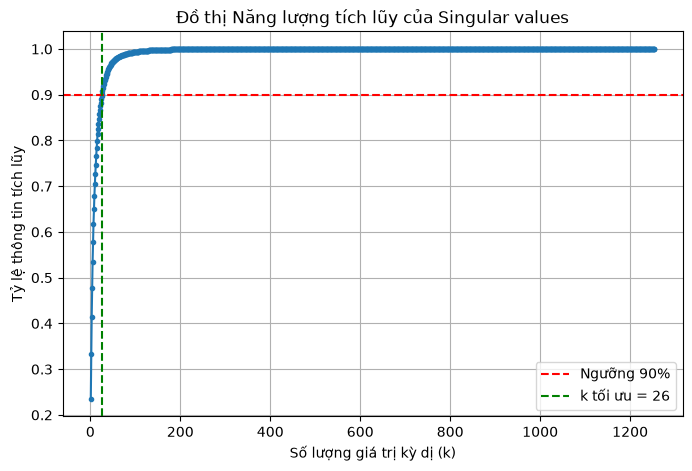

In [10]:
# Bonus
# Dựa trên định lý Eckart-Young-Mirsky

# Chọn đại bức ảnh thứ 2:
M2 = np.array(Image.open("hihi2.png").convert("L"), dtype=float)
M2_mean = np.mean(M2)

M2_centered = M2 - M2_mean
U, S, Vt = np.linalg.svd(M2_centered, full_matrices=False)

energy = S ** 2

# Tính tỉ lệ năng lượng cộng dồn
cumulative_energy = np.cumsum(energy) / np.sum(energy)

# Tìm k tối ưu để giữ lại >= 90% thông tin
# np.argmax tìm vị trí index đầu tiên mà điều kiện (>= 0.90) trả về True
# Cộng 1 vì index trong Python bắt đầu từ 0, còn k là số lượng bắt đầu từ 1
k_optimal = np.argmax(cumulative_energy >= 0.90) + 1 

print(f"Số lượng k cần thiết để giữ >= 90% thông tin là: {k_optimal}")


plt.figure(figsize=(8, 5))

# Trục X là k (từ 1 đến tổng số lượng sigma), Trục Y là phần trăm thông tin tích lũy
plt.plot(range(1, len(cumulative_energy) + 1), cumulative_energy, marker='.', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='Ngưỡng 90%')
plt.axvline(x=k_optimal, color='g', linestyle='--', label=f'k tối ưu = {k_optimal}')


plt.title("Đồ thị Năng lượng tích lũy của Singular values")
plt.xlabel("Số lượng giá trị kỳ dị (k)")
plt.ylabel("Tỷ lệ thông tin tích lũy")
plt.legend()
plt.grid(True)
plt.show()


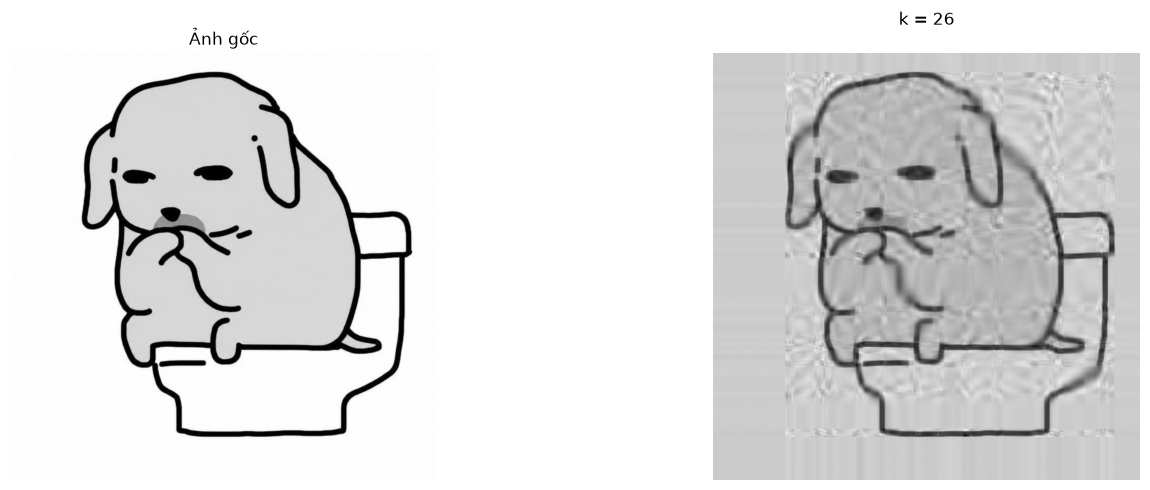

In [11]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.imshow(M2, cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')

M2_k_centered = reconstruct(k_optimal)
M2_k = M2_k_centered + M2_mean

plt.subplot(1, 2, 2)
plt.imshow(M2_k, cmap='gray')
plt.title(f"k = {k_optimal}\n")
plt.axis('off')

plt.tight_layout()
plt.show()


\### Nhận xét Bonus

**Định lý Eckart-Young-Mirsky** phát biểu rằng xấp xỉ hạng-k tốt nhất (theo chuẩn Frobenius) chính là ma trận tái tạo từ k giá trị kỳ dị lớn nhất.  

- Chỉ cần giữ lại k tương ứng 90% năng lượng (σᵢ² / Σσⱼ²), ảnh tái tạo gần như không phân biệt được bằng mắt thường với ảnh gốc.  
- Đây là lý do SVD được dùng rộng rãi trong **nén ảnh**, **hệ thống gợi ý** (collaborative filtering), và **tiền xử lý đặc trưng** trong AI.
